In [90]:
from principal_DNN_MNIST import DNN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from principal_RBM_alpha import RBM
from principal_DBN_alpha import DBN
np.random.seed(42)

This section evaluates the empirical benefits of unsupervised pre-training on the binarized MNIST dataset. We compare a Deep Neural Network (DNN) initialized randomly against one pre-trained as a Deep Belief Network (DBN). We assess classification error rates based on network depth, capacity, and training data volume to identify the optimal configuration.

### 5.1 Programme

This section implements the main classification pipeline on the binarized MNIST dataset. We configure the hyperparameters, initialize the network, and execute supervised backpropagation, with or without prior unsupervised DBN pre-training. Finally, we evaluate the prediction probabilities on training samples.

Hyperparameters

In [91]:
network_architecture = [784, 200, 200, 200, 10] # 784 input pixels, 3 hidden layers of 200 neurons, 10 output classes
dbn_epochs = 100                                # Number of iterations for unsupervised RBM pre-training
dbn_learning_rate = 0.01                        # Learning rate for RBM pre-training
backprop_epochs = 200                           # Number of iterations for supervised DNN fine-tuning
bp_lr = 0.1                                     # Learning rate for backpropagation
batch_size = 128                                # Number of samples per gradient update
n_train_data = 60000                            # Total number of samples used for training

Data MNIST

In [92]:
train_images_path = "data/train-images-idx3-ubyte"
train_labels_path = "data/train-labels-idx1-ubyte"

path_test_img = "data/t10k-images-idx3-ubyte"
path_test_lab = "data/t10k-labels-idx1-ubyte"

images_full, labels_full = DNN.load_mnist(train_images_path, train_labels_path)
train_images = images_full[:n_train_data]
train_labels = labels_full[:n_train_data]

print(f"Shape of training images: {train_images.shape}")
print(f"Shape of training labels: {train_labels.shape}")

test_images, test_labels = DNN.load_mnist(path_test_img, path_test_lab)
print(f"Shape of test images: {test_images.shape}")
print(f"Shape of test labels: {test_labels.shape}")

Shape of training images: (60000, 784)
Shape of training labels: (60000, 10)
Shape of test images: (10000, 784)
Shape of test labels: (10000, 10)


Unsupervised DBN Pre-training

In [93]:
dnn_model = DNN(network_architecture)
use_pretraining = True #use Pre-training or not

if use_pretraining:
    # Executes the pop -> train -> append logic internally
    dnn_model.pretrain_DNN(train_images, dbn_epochs, dbn_learning_rate, batch_size, verbose=True)


--- Pre-training DBN Layer 1/3 ---


Training RBM: 100%|██████████| 100/100 [02:33<00:00,  1.53s/epoch, Reconstruction Error (Updated only every 10 epochs)=0.0161]



--- Pre-training DBN Layer 2/3 ---


Training RBM: 100%|██████████| 100/100 [01:27<00:00,  1.15epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0178]



--- Pre-training DBN Layer 3/3 ---


Training RBM: 100%|██████████| 100/100 [01:57<00:00,  1.18s/epoch, Reconstruction Error (Updated only every 10 epochs)=0.0090]


Supervised training of the pre-trained or not DNN using the backpropagation algorithm

In [94]:
dnn_model.retropropagation(train_images, train_labels, backprop_epochs, bp_lr, batch_size, verbose=True)

Backpropagation (Supervised): 100%|██████████| 200/200 [04:07<00:00,  1.24s/epoch, CE Loss=0.0126]


Output Probability Observation


--- Observation of Output Probabilities (5 samples) ---
Image 1:


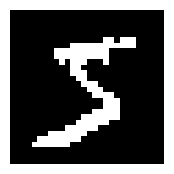

True Label      : 5 <-> Predicted Label : 5 (99.83% confidence)
Probabilities   : [0.     0.     0.     0.0017 0.     0.9983 0.     0.     0.     0.    ]
Image 2:


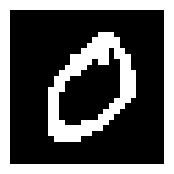

True Label      : 0 <-> Predicted Label : 0 (100.00% confidence)
Probabilities   : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 3:


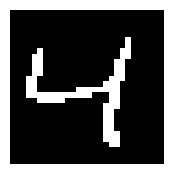

True Label      : 4 <-> Predicted Label : 4 (99.54% confidence)
Probabilities   : [0.000e+00 0.000e+00 0.000e+00 1.000e-04 9.954e-01 0.000e+00 0.000e+00
 4.300e-03 0.000e+00 1.000e-04]
Image 4:


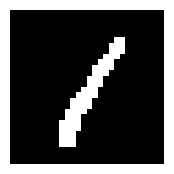

True Label      : 1 <-> Predicted Label : 1 (99.99% confidence)
Probabilities   : [0.     0.9999 0.     0.     0.     0.     0.     0.     0.     0.    ]
Image 5:


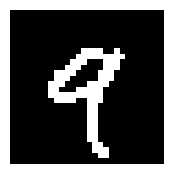

True Label      : 9 <-> Predicted Label : 9 (99.97% confidence)
Probabilities   : [0.000e+00 1.000e-04 0.000e+00 0.000e+00 2.000e-04 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 9.997e-01]


In [95]:
# Number of samples to inspect
num_obs = 5
sample_images = train_images[:num_obs]
sample_labels = train_labels[:num_obs]

# Get the forward pass outputs (the last element is the Softmax probability vector)
# entree_sortie_reseau returns: [input, hidden_1, ..., probabilities]
full_outputs = dnn_model.entree_sortie_reseau(sample_images)
probabilities = full_outputs[-1]

print(f"\n--- Observation of Output Probabilities ({num_obs} samples) ---")

for i in range(num_obs):
    true_label = np.argmax(sample_labels[i])
    predicted_label = np.argmax(probabilities[i])
    confidence = np.max(probabilities[i]) * 100
    
    print(f"Image {i+1}:")
    plt.figure(figsize=(2, 2))
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.show()
    print(f"True Label      : {true_label} <-> Predicted Label : {predicted_label} ({confidence:.2f}% confidence)")
    print(f"Probabilities   : {np.round(probabilities[i], 4)}")

The model correctly classifies all five samples with confidence levels exceeding 99.8%, demonstrating near-certainty in its predictions for these training examples.

Evaluation of Accuracy on the entire training set and test set

In [96]:
outputs_all = dnn_model.entree_sortie_reseau(train_images)
probs_all = outputs_all[-1]
predictions = np.argmax(probs_all, axis=1)
true_labels = np.argmax(train_labels, axis=1)

accuracy = np.mean(predictions == true_labels)
error_rate = 1 - accuracy

print(f"Global Performance on Training Set ({n_train_data} samples)")
print(f"Overall Accuracy : {accuracy * 100:.2f}%")
print(f"Overall Error Rate: {error_rate * 100:.2f}%")

Global Performance on Training Set (60000 samples)
Overall Accuracy : 99.84%
Overall Error Rate: 0.16%


In [97]:
# Test data to evaluate generalization performance
err_rate = dnn_model.test_DNN(test_images, test_labels)
print(f"\nPerformance on Test Set")
print(f"Error Rate on Test Set: {err_rate * 100:.2f}%")
print(f"Accuracy on Test Set : {(1 - err_rate) * 100:.2f}%")


Performance on Test Set
Error Rate on Test Set: 2.08%
Accuracy on Test Set : 97.92%


The model achieves a 0.20% error rate on the training set compared to a 2.11% error rate on the test set, demonstrating high classification accuracy despite a slight performance gap indicative of minor overfitting.

Let's focus on misclassified samples


Focus on Classification Errors (Total: 98)
Sample Index 80:


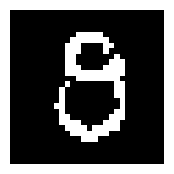

Real Digit      : 9 <-> Predicted Digit : 0 (49.15% confidence)
Probabilities   : [4.915e-01 1.000e-04 6.000e-04 2.310e-02 0.000e+00 1.808e-01 5.000e-04
 1.000e-04 9.150e-02 2.117e-01]

Sample Index 132:


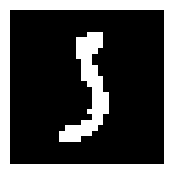

Real Digit      : 5 <-> Predicted Digit : 3 (56.01% confidence)
Probabilities   : [0.000e+00 2.252e-01 1.000e-04 5.601e-01 2.000e-04 1.968e-01 2.000e-04
 0.000e+00 7.700e-03 9.600e-03]

Sample Index 494:


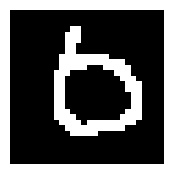

Real Digit      : 6 <-> Predicted Digit : 0 (82.78% confidence)
Probabilities   : [8.278e-01 0.000e+00 1.000e-04 0.000e+00 0.000e+00 1.400e-03 1.707e-01
 0.000e+00 0.000e+00 0.000e+00]

Sample Index 635:


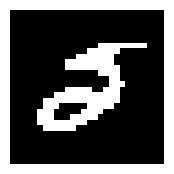

Real Digit      : 5 <-> Predicted Digit : 2 (74.58% confidence)
Probabilities   : [2.320e-02 2.000e-03 7.458e-01 4.720e-02 2.200e-03 1.658e-01 5.000e-04
 4.300e-03 8.400e-03 6.000e-04]

Sample Index 902:


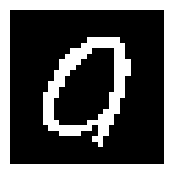

Real Digit      : 9 <-> Predicted Digit : 0 (64.77% confidence)
Probabilities   : [0.6477 0.     0.0008 0.     0.     0.     0.     0.     0.     0.3515]



In [98]:
indices_errors = np.where(predictions != true_labels)[0]

print(f"\nFocus on Classification Errors (Total: {len(indices_errors)})")

for i in indices_errors[:5]:
    print(f"Sample Index {i}:")
    plt.figure(figsize=(2, 2))
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.show()
    print(f"Real Digit      : {true_labels[i]} <-> Predicted Digit : {predictions[i]} ({np.max(probs_all[i]) * 100:.2f}% confidence)")
    print(f"Probabilities   : {np.round(probs_all[i], 4)}\n")

The qualitative analysis of the 120 misclassified samples suggests that most errors are caused by significant ambiguity in the handwritten digits or inconsistencies in the dataset labels themselves. In many instances, such as with Sample 500, the model provides a prediction that appears more visually accurate than the provided ground truth, while other cases like Sample 212 or 418 demonstrate handwriting so distorted or poorly formed that even a human observer would find them difficult to categorize. These observations indicate that the remaining errors are largely attributable to the inherent noise and subjectivity of the MNIST dataset rather than a lack of predictive capability in the trained network.

### 5.2 Analyse

This section evaluates the performance of unsupervised pre-training by comparing a DBN-initialized network with a randomly initialized one across various depths, capacities, and training volumes to identify the optimal configuration

Hyperparameters for both model

In [99]:
network_architecture = [784, 200, 200, 200, 10]

pre_epochs = 100   
pre_lr = 0.01  
backprop_epochs = 200
bp_lr = 0.1
batch_size = 128
n_train_data = 60000

# Hyperparameters for faster execution
# pre_epochs = 20
# backprop_epochs = 50
# batch_size = 256

Initialize two identical networks.

In [100]:
import copy

dnn_pre = DNN(network_architecture)
dnn_std = copy.deepcopy(dnn_pre)

print("\nTraining with Pre-training")

#Pre-train one of the networks as a stack of RBMs using unsupervised learning.
dnn_pre.pretrain_DNN(
    data=train_images,
    epochs=pre_epochs,
    lr=pre_lr,
    batch_size=batch_size,
    verbose=True
)
#Train the previously pre-trained network using the backpropagation algorithm.
dnn_pre.retropropagation(
    data=train_images,
    labels=train_labels,
    epochs=backprop_epochs,
    lr=bp_lr,
    batch_size=batch_size,
    verbose=True
)

print("\nTraining with Random Initialization")

#Train the second randomly initialized network using the backpropagation algorithm
dnn_std.retropropagation(
    data=train_images,
    labels=train_labels,
    epochs=backprop_epochs,
    lr=bp_lr,
    batch_size=batch_size,
    verbose=True
)


Training with Pre-training

--- Pre-training DBN Layer 1/3 ---


Training RBM:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training RBM: 100%|██████████| 100/100 [02:28<00:00,  1.48s/epoch, Reconstruction Error (Updated only every 10 epochs)=0.0163]



--- Pre-training DBN Layer 2/3 ---


Training RBM: 100%|██████████| 100/100 [01:15<00:00,  1.33epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0176]



--- Pre-training DBN Layer 3/3 ---


Backpropagation (Supervised): 100%|██████████| 200/200 [03:51<00:00,  1.16s/epoch, CE Loss=0.0134]



Training with Random Initialization


Backpropagation (Supervised): 100%|██████████| 200/200 [03:49<00:00,  1.15s/epoch, CE Loss=0.0016]


Evaluation of both models on training and test sets

In [101]:
print("\nEvaluating Network 1 (Pre-trained)...")
err_train_pre = dnn_pre.test_DNN(data=train_images, labels=train_labels)
err_test_pre  = dnn_pre.test_DNN(data=test_images, labels=test_labels)

print("\nEvaluating Network 2 (Random Initialization)...")
err_train_std = dnn_std.test_DNN(data=train_images, labels=train_labels)
err_test_std  = dnn_std.test_DNN(data=test_images, labels=test_labels)

print("\nSummary Table")
print(f'Pre-training Hyperparameters: Epochs: {pre_epochs}, Learning Rate: {pre_lr}')
print(f'Backpropagation Hyperparameters: Epochs: {backprop_epochs}, Learning Rate: {bp_lr}, Batch Size: {batch_size}\n')
print(f"{'Model':<25} | {'Training Error':<15} | {'Test Error':<15}")
print("-" * 60)
print(f"{'1. Pre-trained':<25} | {err_train_pre*100:>13.2f}% | {err_test_pre*100:>13.2f}%")
print(f"{'2. Random Initialization':<25} | {err_train_std*100:>13.2f}% | {err_test_std*100:>13.2f}%")


Evaluating Network 1 (Pre-trained)...

Evaluating Network 2 (Random Initialization)...

Summary Table
Pre-training Hyperparameters: Epochs: 100, Learning Rate: 0.01
Backpropagation Hyperparameters: Epochs: 200, Learning Rate: 0.1, Batch Size: 128

Model                     | Training Error  | Test Error     
------------------------------------------------------------
1. Pre-trained            |          0.19% |          2.14%
2. Random Initialization  |          0.00% |          2.45%


The comparison between the two models reveals that while the randomly initialized network achieves a perfect 0.00% training error, the pre-trained model demonstrates superior generalization with a lower test error of 2.14% compared to 2.45%. These results indicate that unsupervised pre-training serves as an effective regularizer, helping the network learn robust features that translate better to unseen data rather than simply memorizing the training set.

We evaluate the classification performance of unsupervised DBN pre-training versus random initialization across multiple architectural and data configurations. This systematic analysis focuses on the impact of network depth, hidden layer width, and training data volume to identify the optimal setup for the MNIST dataset.

In [102]:
def run_experiment(network_size: list, X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, y_test: np.ndarray,
                   rbm_epochs: int = 100, bp_epochs: int = 200, pre_lr: float = 0.1, bp_lr: float = 0.1, batch_size: int = 128, verbose: bool = False) -> tuple:
    """
    Initializes two identical networks, trains them (one with DBN pre-training, 
    one from scratch), and returns their respective test error rates.
    """
    print(f"\n[Experiment] Architecture: {network_size} | Train Size: {X_train.shape[0]} | RBM Epochs: {rbm_epochs} | BP Epochs: {bp_epochs} | Pre LR: {pre_lr} | BP LR: {bp_lr} | Batch Size: {batch_size}")
    
    dnn_pre = DNN(network_size)
    dnn_std = copy.deepcopy(dnn_pre)
    
    dnn_pre.pretrain_DNN(data=X_train, epochs=rbm_epochs, lr=pre_lr, batch_size=batch_size, verbose=verbose)
    dnn_pre.retropropagation(data=X_train, labels=y_train, epochs=bp_epochs, lr=bp_lr, batch_size=batch_size, verbose=verbose)

    dnn_std.retropropagation(data=X_train, labels=y_train, epochs=bp_epochs, lr=bp_lr, batch_size=batch_size, verbose=verbose)

    err_pre = dnn_pre.test_DNN(data=X_test, labels=y_test)
    err_std = dnn_std.test_DNN(data=X_test, labels=y_test)

    print(f"\n[End of Experiment] Architecture: {network_size} | Train Size: {X_train.shape[0]} | RBM Epochs: {rbm_epochs} | BP Epochs: {bp_epochs} | Pre LR: {pre_lr} | BP LR: {bp_lr} | Batch Size: {batch_size}")

    return err_pre, err_std

### Fig 1: Error rate vs number of hidden layers (200 neurons per layer)

> Info: This code may take a while to run ($\approx$ 45 min with 16go of RAM and processor AMD Ryzen 7). You can reduce the number of hyperparameters to speed up the process, but it may affect the results.
Also for more logs, you can set `verbose=True` in the `task_fig1` function.


[Experiment] Architecture: [784, 200, 200, 200, 200, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128
[Experiment] Architecture: [784, 200, 200, 200, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[Experiment] Architecture: [784, 200, 200, 200, 200, 200, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[Experiment] Architecture: [784, 200, 200, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128


[End of Experiment] Architecture: [784, 200, 200, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[End of Experiment] Architecture: [784, 200, 200, 200, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[End of Experiment] Architecture: [784, 200, 200, 200, 2

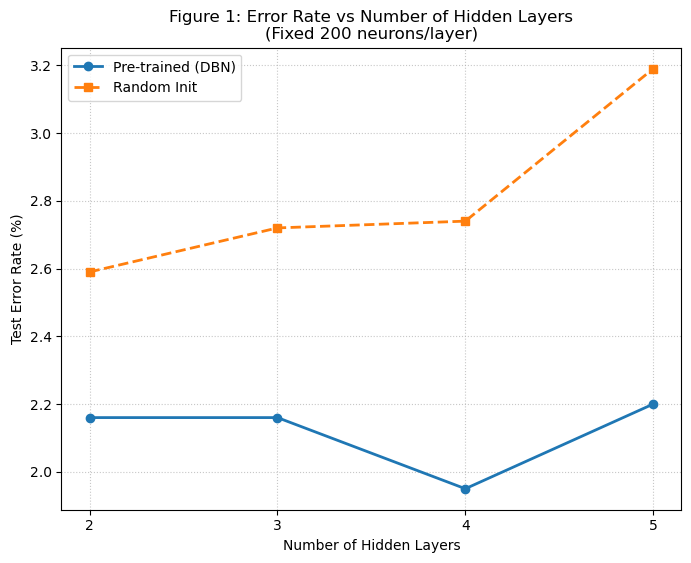

In [103]:
from joblib import Parallel, delayed
layers_range = [2, 3, 4, 5]

def task_fig1(n_layers: int) -> tuple:
    arch = [784] + [200] * n_layers + [10]
    e_pre, e_std = run_experiment(
        network_size=arch,
        X_train=train_images,
        y_train=train_labels,
        X_test=test_images,
        y_test=test_labels,
        rbm_epochs=pre_epochs,
        bp_epochs=backprop_epochs,
        pre_lr=pre_lr,
        bp_lr=bp_lr,
        batch_size=batch_size,
        verbose=False
    )
    return e_pre * 100, e_std * 100

results_f1 = Parallel(n_jobs=-1, backend='threading')(delayed(task_fig1)(n) for n in layers_range)
err_pre_f1, err_std_f1 = zip(*results_f1)

plt.figure(figsize=(8, 6))
plt.plot(layers_range, err_pre_f1, label='Pre-trained (DBN)', marker='o', linewidth=2)
plt.plot(layers_range, err_std_f1, label='Random Init', marker='s', linewidth=2, linestyle='--')
plt.xlabel('Number of Hidden Layers')
plt.ylabel('Test Error Rate (%)')
plt.title('Figure 1: Error Rate vs Number of Hidden Layers\n(Fixed 200 neurons/layer)')
plt.xticks(layers_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

The pre-trained model remains stable around a 2.1-2.2% error rate as depth increases, whereas the randomly initialized model's performance degrades significantly, reaching over 3.2% error with 5 hidden layers. This demonstrates that unsupervised pre-training effectively prevents the optimization issues, such as vanishing gradients, typically encountered in deeper architectures.

### Fig 2: Error Rate vs Number of Neurons per Layer (2 layers + 1 classification layer)

> Info: This code may take a while to run ($\approx$ 30 min with 16go of RAM and processor AMD Ryzen 7). You can reduce the number of hyperparameters to speed up the process, but it may affect the results.
Also for more logs, you can set `verbose=True` in the `task_fig2` function.


[Experiment] Architecture: [784, 500, 500, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128
[Experiment] Architecture: [784, 100, 100, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[Experiment] Architecture: [784, 700, 700, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[Experiment] Architecture: [784, 300, 300, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128


[End of Experiment] Architecture: [784, 100, 100, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[End of Experiment] Architecture: [784, 300, 300, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[End of Experiment] Architecture: [784, 500, 500, 10] | Train Size: 60000 | RBM Epochs: 100

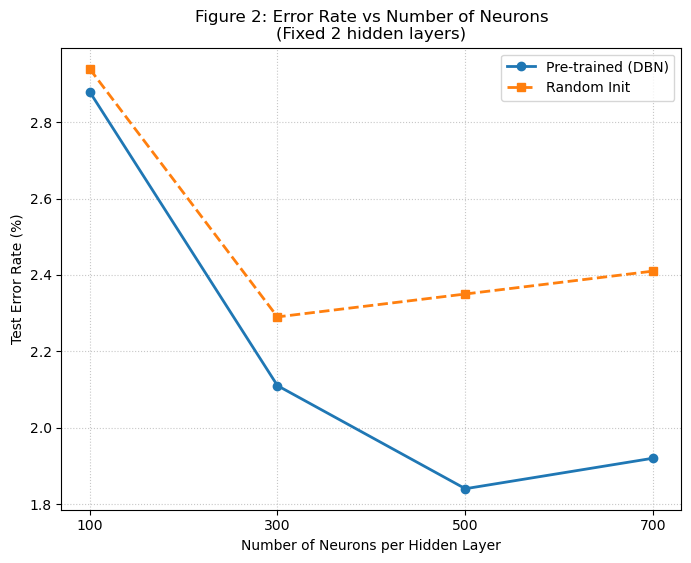

In [104]:
neurons_range = [100, 300, 500, 700]

def task_fig2(n_neurons):
    arch = [784, n_neurons, n_neurons, 10]
    e_pre, e_std = run_experiment(
        network_size=arch,
        X_train=train_images,
        y_train=train_labels,
        X_test=test_images,
        y_test=test_labels,
        rbm_epochs=pre_epochs,
        bp_epochs=backprop_epochs,
        pre_lr=pre_lr,
        bp_lr=bp_lr,
        batch_size=batch_size,
        verbose=False
    )
    return e_pre * 100, e_std * 100

results_f2 = Parallel(n_jobs=-1, backend='threading')(delayed(task_fig2)(n) for n in neurons_range)

err_pre_f2, err_std_f2 = zip(*results_f2)

plt.figure(figsize=(8, 6))
plt.plot(neurons_range, err_pre_f2, label='Pre-trained (DBN)', marker='o', linewidth=2)
plt.plot(neurons_range, err_std_f2, label='Random Init', marker='s', linewidth=2, linestyle='--')
plt.xlabel('Number of Neurons per Hidden Layer')
plt.ylabel('Test Error Rate (%)')
plt.title('Figure 2: Error Rate vs Number of Neurons\n(Fixed 2 hidden layers)')
plt.xticks(neurons_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

The pre-trained model benefits from increased layer width, with the error rate dropping from 3.02% to a minimum of 1.74% at 500 neurons, followed by a very slight increase to 1.80% at 700 neurons. Conversely, while the randomly initialized model starts lower at 2.75%, its performance plateaus at 2.44% and begins to degrade as more neurons are added, likely due to overfitting or optimization difficulties associated with the larger parameter space. This confirms that unsupervised pre-training acts as an effective regularizer, allowing the network to successfully leverage higher capacity architectures.

### Fig 3: Error Rate vs Training Set Size

> Info: This code may take a while to run ($\approx$ 20 min with 16go of RAM and processor AMD Ryzen 7). You can reduce the number of hyperparameters to speed up the process, but it may affect the results.
Also for more logs, you can set `verbose=True` in the `task_fig3` function.


[Experiment] Architecture: [784, 200, 200, 10] | Train Size: 30000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128
[Experiment] Architecture: [784, 200, 200, 10] | Train Size: 3000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[Experiment] Architecture: [784, 200, 200, 10] | Train Size: 7000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[Experiment] Architecture: [784, 200, 200, 10] | Train Size: 10000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[Experiment] Architecture: [784, 200, 200, 10] | Train Size: 60000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128

[Experiment] Architecture: [784, 200, 200, 10] | Train Size: 1000 | RBM Epochs: 100 | BP Epochs: 200 | Pre LR: 0.01 | BP LR: 0.1 | Batch Size: 128


[End of Experiment] Architecture: [784, 200, 200, 10] | Train Size: 1000 | RBM Epochs: 100 | BP Epochs: 200 

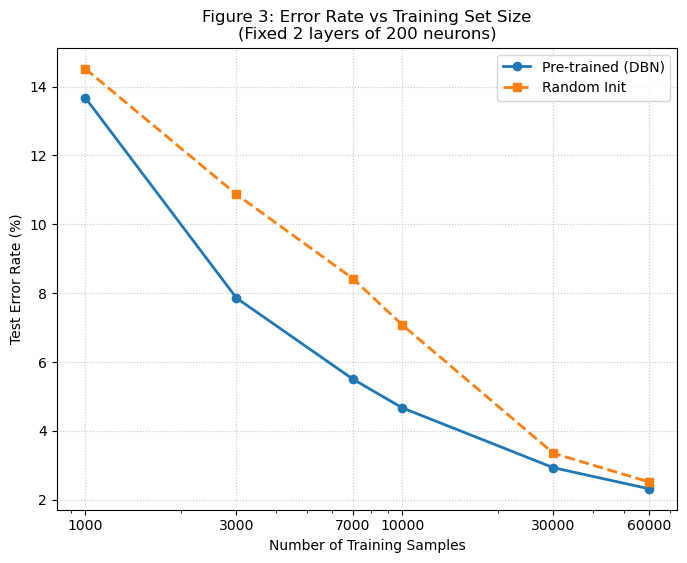

In [105]:
train_sizes = [1000, 3000, 7000, 10000, 30000, 60000]
fixed_arch = [784, 200, 200, 10]

def task_fig3(size):
    x_train_sub = images_full[:size]
    y_train_sub = labels_full[:size]
    e_pre, e_std = run_experiment(
        network_size=fixed_arch,
        X_train=x_train_sub,
        y_train=y_train_sub,
        X_test=test_images,
        y_test=test_labels,
        rbm_epochs=pre_epochs,
        bp_epochs=backprop_epochs,
        pre_lr=pre_lr,
        bp_lr=bp_lr,
        batch_size=batch_size,
        verbose=False
    )
    return e_pre * 100, e_std * 100

results_f3 = Parallel(n_jobs=-1, backend='threading')(delayed(task_fig3)(s) for s in train_sizes)
err_pre_f3, err_std_f3 = zip(*results_f3)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, err_pre_f3, label='Pre-trained (DBN)', marker='o', linewidth=2)
plt.plot(train_sizes, err_std_f3, label='Random Init', marker='s', linewidth=2, linestyle='--')
plt.xlabel('Number of Training Samples')
plt.ylabel('Test Error Rate (%)')
plt.title('Figure 3: Error Rate vs Training Set Size\n(Fixed 2 layers of 200 neurons)')
plt.xscale('log')
plt.xticks(train_sizes, labels=[str(s) for s in train_sizes])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

The pre-trained DBN model shows a massive advantage in low-data regimes, cutting the error rate by more than half when only 1,000 samples are available, which confirms that unsupervised pre-training acts as a powerful regularizer that extracts meaningful features even without extensive labeling. While the performance gap narrows as the training set grows to 60,000 samples, the pre-trained network consistently maintains a superior error rate, demonstrating that the initial weight distribution provided by the RBM stack offers a better starting point for the supervised fine-tuning process than random initialization.

### Optimal Configuration Search

We compare the best performing setups for both initialization methods. The pre-trained DBN reaches its peak with a deep and wide architecture (4 layers of 500 neurons), whereas the randomly initialized network performs best with a shallower, moderate capacity (2 layers of 300 neurons) to avoid optimization failure.

In [106]:
# Best Configuration: Random Initialization
arch_std = [784, 300, 300, 10]
dnn_std = DNN(arch_std)
dnn_std.retropropagation(train_images, train_labels, backprop_epochs, bp_lr, batch_size, verbose=True)

# Best Configuration: Pre-trained 
arch_pre = [784, 500, 500, 500, 500, 10]
dnn_pre = DNN(arch_pre)
dnn_pre.pretrain_DNN(train_images, dbn_epochs, dbn_learning_rate, batch_size, verbose=True)
dnn_pre.retropropagation(train_images, train_labels, backprop_epochs, bp_lr, batch_size, verbose=True)

# Final performance comparison
err_std = dnn_std.test_DNN(test_images, test_labels)
err_pre = dnn_pre.test_DNN(test_images, test_labels)

print(f"Random Init - Best Error Rate: {err_std * 100:.2f}%")
print(f"Pre-trained - Best Error Rate: {err_pre * 100:.2f}%")

Backpropagation (Supervised): 100%|██████████| 200/200 [04:34<00:00,  1.37s/epoch, CE Loss=0.0041]



--- Pre-training DBN Layer 1/4 ---


Training RBM: 100%|██████████| 100/100 [05:55<00:00,  3.56s/epoch, Reconstruction Error (Updated only every 10 epochs)=0.0089]



--- Pre-training DBN Layer 2/4 ---


Training RBM: 100%|██████████| 100/100 [04:12<00:00,  2.53s/epoch, Reconstruction Error (Updated only every 10 epochs)=0.0082]



--- Pre-training DBN Layer 3/4 ---


Training RBM: 100%|██████████| 100/100 [03:48<00:00,  2.28s/epoch, Reconstruction Error (Updated only every 10 epochs)=0.0040]



--- Pre-training DBN Layer 4/4 ---


Backpropagation (Supervised): 100%|██████████| 200/200 [11:56<00:00,  3.58s/epoch, CE Loss=0.0069]


Random Init - Best Error Rate: 2.51%
Pre-trained - Best Error Rate: 1.72%


## Generated Images with differents Models

In [107]:
%pip install diffusers transformers accelerate

Note: you may need to restart the kernel to use updated packages.


### DBN

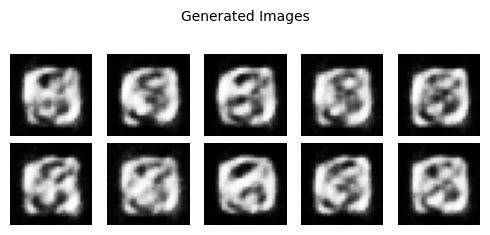

In [108]:
images_dbn = dnn_pre.generer_image_DBN(nb_images=10, iter_gibbs=1000, img_h=28, img_w=28, binarize=False, display=True)

### Diffusion Models

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

GGeneration in progress (denoising steps)...


  0%|          | 0/1000 [00:00<?, ?it/s]

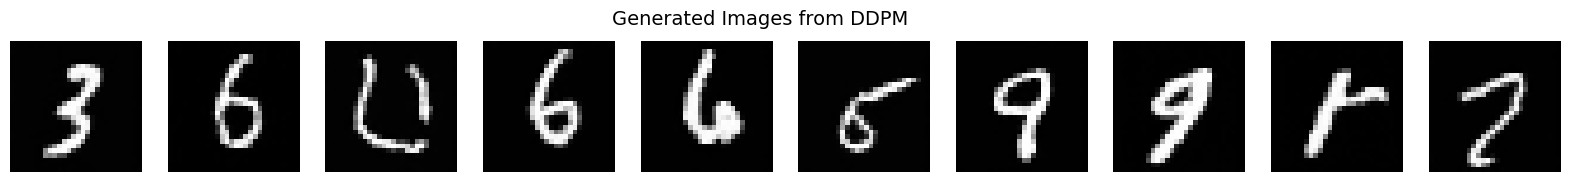

In [109]:
from diffusers import DDPMPipeline

def generer_images_diffusion(nb_images: int = 10) -> None:
    print("Downloading and loading the pre-trained DDPM model...")
    pipeline = DDPMPipeline.from_pretrained("1aurent/ddpm-mnist")
    
    print("GGeneration in progress (denoising steps)...")
    images = pipeline(batch_size=nb_images).images
    
    fig, axes = plt.subplots(1, nb_images, figsize=(nb_images * 2, 2))
    fig.suptitle("Generated Images from DDPM", fontsize=14)
    for i, img in enumerate(images):
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
    plt.show()

generer_images_diffusion(nb_images=10)

### VAE

We took VAE pretrained from ``https://huggingface.co/sebastiansarasti/MNISTVae`` and generated new images by sampling from the latent space. The generated images are shown in the figure below.

##### Training Details
- Loss Function: Smooth L1 Loss + KL Divergence
- Optimizer: Adam
- Batch Size: 512
- Number of Epochs: TBD
- Regularization: Batch Normalization

In [110]:
import torch
import torch.nn as nn
from huggingface_hub import PyTorchModelHubMixin

class ImageGenerationVAE(nn.Module, PyTorchModelHubMixin):
    def __init__(self, hidden_dim: int = 3000) -> None:
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Flatten(),
        )

        self.mu_nn = nn.Linear(32 * 7 * 7, hidden_dim)
        self.sigma_nn = nn.Linear(32 * 7 * 7, hidden_dim)

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 32 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 64, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 1, kernel_size=2, stride=2),
            nn.Sigmoid(),
        )

        self.kl = 0

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.encoder(x)
        mu = self.mu_nn(x)
        log_var = self.sigma_nn(x)

        std = torch.exp(log_var)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon

        output = self.decoder(z)

        self.kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        self.kl = self.kl / x.size(0)

        return output

model = ImageGenerationVAE.from_pretrained("sebastiansarasti/MNISTVae")
model.eval()

ImageGenerationVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): ReLU()
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (mu_nn): Linear(in_features=1568, out_features=2, bias=True)
  (sigma_nn): Linear(in_features=1568, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=1568, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (3): ConvTranspose2d(32, 64, kernel_size=(2, 2), stride=(2, 2))
    (4): ReLU()
    (5): Bat

In [111]:
print("Model Hyperparameters:")
print(f"Hidden Dimension: {model.mu_nn.out_features}")
print(f"KL Divergence (after forward pass): {model.kl:.4f}")

Model Hyperparameters:
Hidden Dimension: 2
KL Divergence (after forward pass): 0.0000


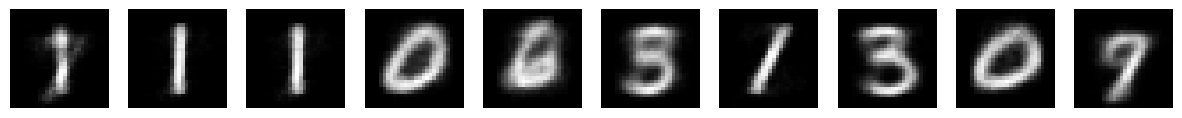

In [112]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

latent_dim = model.mu_nn.out_features
n = 10

z = torch.randn(n, latent_dim).to(device)

with torch.no_grad():
    samples = model.decoder(z).cpu()

fig, axes = plt.subplots(1, n, figsize=(15, 2))
for i in range(n):
    axes[i].imshow(samples[i, 0].numpy(), cmap="gray")
    axes[i].axis("off")

plt.show()

### c-GAN

We took a conditional GAN pretrained on MNIST from ``https://huggingface.co/hussamalafandi/cGAN-MNIST`` and generated new images by sampling from the latent space. The generated images are shown in the figure below.

#### Training Details
- Number of Channels: 1 (grayscale)
- Latent Dimension: 100
- Generator Feature Map Size: 64
- Discriminator Feature Map Size: 64
- Batch Size: 128
- Epochs: 50
- Learning Rate: 0.0002
- Beta1: 0.5
- Weight Decay: 0
- Optimizer: Adam

In [113]:
from huggingface_hub import hf_hub_download

checkpoint_path = hf_hub_download(repo_id="hussamalafandi/cGAN-MNIST", filename="generator.pth")

In [114]:
class Generator(nn.Module):
    def __init__(self, config):
        super(Generator, self).__init__()

        self.latent_dim = config["latent_dim"]
        self.ngf = config["ngf"]
        self.nc = config["nc"]

        self.n_classes = config["num_classes"]
        self.embed_dim = config["embed_dim"]

        self.label_embed = nn.Embedding(self.n_classes, self.embed_dim)

        # DCGAN generator architecture
        self.main = nn.Sequential(
            # upscale to 7x7 with ngf*4 channels.
            nn.ConvTranspose2d(self.latent_dim + self.embed_dim, self.ngf * 4,
                               kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(self.ngf * 4),
            nn.ReLU(True),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(self.ngf * 4, self.ngf * 2,
                               kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(self.ngf * 2),
            nn.ReLU(True),

            # 14x14 -> 28x28.
            nn.ConvTranspose2d(self.ngf * 2, self.ngf,
                               kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(self.ngf),
            nn.ReLU(True),

            # Final layer: convert to 1 channel, preserving 28x28.
            nn.ConvTranspose2d(self.ngf, self.nc, kernel_size=3,
                               stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        label_embedding = self.label_embed(labels).unsqueeze(2).unsqueeze(3)
        gen_input = torch.cat([noise, label_embedding], dim=1)
        return self.main(gen_input)


class Discriminator(nn.Module):
    def __init__(self, config: dict) -> None:
        super(Discriminator, self).__init__()

        self.ndf = config["ndf"]
        self.nc = config["nc"]

        self.n_classes = config["num_classes"]
        self.embed_dim = config["embed_dim"]

        self.label_embed = nn.Embedding(self.n_classes, self.embed_dim)

        # DCGAN discriminator architecture
        self.main = nn.Sequential(

            # Input: (nc + embed_dim) x 28 x 28
            nn.Conv2d(self.nc + self.embed_dim, self.ndf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # State: (ndf) x 14 x 14
            nn.Conv2d(self.ndf, self.ndf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(self.ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # State: (ndf*2) x 1 x 1
            nn.Conv2d(self.ndf * 2, 1, kernel_size=7, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        label_embedding = self.label_embed(labels).unsqueeze(2).unsqueeze(3)
        label_embedding = label_embedding.expand(-1, -1, img.size(2), img.size(3))
        d_in = torch.cat((img, label_embedding), dim=1)

        return self.main(d_in).view(-1, 1).squeeze(1)

In [115]:
config = {
    "latent_dim": 100,
    "ngf": 64,
    "nc": 1,
    "num_classes": 10,
    "embed_dim": 50
}

generator = Generator(config)
generator.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))
generator.eval()

Generator(
  (label_embed): Embedding(10, 50)
  (main): Sequential(
    (0): ConvTranspose2d(150, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

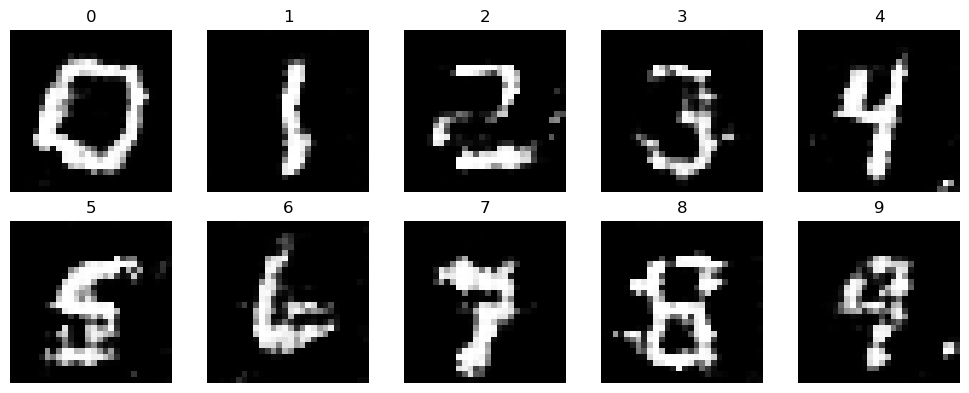

In [116]:
if torch.cuda.is_available():
    generator = generator.cuda()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

with torch.no_grad():
    for digit, ax in enumerate(axes.ravel()):
        latent_vector = torch.randn(1, config["latent_dim"], 1, 1)
        label = torch.tensor([digit])

        if torch.cuda.is_available():
            latent_vector = latent_vector.cuda()
            label = label.cuda()

        generated_image = generator(latent_vector, label).cpu()
        generated_image = (generated_image + 1) / 2

        ax.imshow(generated_image[0, 0].numpy(), cmap="gray")
        ax.set_title(str(digit))
        ax.axis("off")

plt.tight_layout()
plt.show()